# The Shell Theorem -- Feynman/Newton's Geometric Proof

Griffiths gets the field of a uniformly charged spherical shell two ways: Gauss's
law (`gauss_sphere` in `griffiths/electrostatics.py`, trivial given the symmetry)
and brute-force Coulomb integration (`shell_field_coulomb`, "the hard way" --
law of cosines, elementary but opaque). Neither one tells you *why* the interior
field vanishes in a way you could see coming.

Newton's original proof (for gravity; Feynman re-derives it for the electric
case in the *Lectures*, Vol. II §5-3) does. It's a geometric argument, not an
integral: an interior point P sees the shell through every possible thin double
cone, and each cone's near patch and far patch contribute **exactly equal and
opposite** field -- for a reason that only works because the force law is
$1/r^2$. This notebook derives that cancellation symbolically (not asserted,
*proved*), visualizes it, and then cross-checks the interior/exterior result
against both existing `griffiths/electrostatics.py` functions and a numerical
double integral over the shell.


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from griffiths.electrostatics import shell_field_coulomb, gauss_sphere, KE, eps0

sp.init_printing()
print("sympy", sp.__version__, "| numpy", np.__version__)


sympy 1.14.0 | numpy 2.4.4


## Setup: a ray through an interior point

Put the shell's center at the origin, radius $R$. Let $P$ be an interior point
at distance $d<R$ along the $z$-axis, and consider the full line through $P$ in
direction $\hat n=(\sin\alpha,0,\cos\alpha)$. That line hits the sphere twice --
once "forward" ($t_1>0$) and once "backward" ($t_2<0$) -- at
$Q_i = P + t_i\hat n$. Substituting into $|Q_i|^2=R^2$ gives a quadratic in
$t$; we solve it symbolically rather than just citing the result.


In [2]:
d, R, alpha, t = sp.symbols('d R alpha t', positive=False, real=True)
n_hat = sp.Matrix([sp.sin(alpha), 0, sp.cos(alpha)])
P = sp.Matrix([0, 0, d])

Q = P + t*n_hat
quadratic = sp.expand(Q.dot(Q) - R**2)
quadratic = sp.collect(quadratic, t)
print("quadratic in t:  ", quadratic, " = 0")

roots = sp.solve(sp.Eq(quadratic, 0), t)
t1, t2 = roots            # sympy returns them in a fixed order; we assign generically
print("\nroots:")
for r in roots:
    print(" ", sp.simplify(r))

# Vieta's-formula sanity check against the quadratic's own coefficients
sum_expected = -2*d*sp.cos(alpha)
prod_expected = -(R**2 - d**2)
assert sp.simplify(sum(roots) - sum_expected) == 0
assert sp.simplify(sp.prod(roots) - prod_expected) == 0
print("\nVieta check:  t1+t2 =", sp.simplify(sum(roots)), " (= -2 d cos alpha)")
print("              t1*t2 =", sp.simplify(sp.prod(roots)), " (= -(R^2-d^2), negative since P is interior)")


quadratic in t:   -R**2 + d**2 + 2*d*t*cos(alpha) + t**2*(sin(alpha)**2 + cos(alpha)**2)  = 0



roots:
  -d*cos(alpha) - sqrt(R**2 - d**2*sin(alpha)**2)
  -d*cos(alpha) + sqrt(R**2 - d**2*sin(alpha)**2)

Vieta check:  t1+t2 = -2*d*cos(alpha)  (= -2 d cos alpha)
              t1*t2 = -R**2 + d**2  (= -(R^2-d^2), negative since P is interior)


## The key lemma: the two cone angles are equal and opposite

At each intersection point $Q_i$, the local *outward normal* is $Q_i/R$. The
angle $\theta_i$ between the ray direction $\hat n$ and that normal sets how
much shell area the cone subtends there: a solid angle $d\Omega$ cuts out patch
area $dA_i = r_i^2\,d\Omega/|\cos\theta_i|$ (the $1/\cos\theta$ is the same
projection factor as looking at a tilted surface).

We compute $\cos\theta_i=\hat n\cdot Q_i/R$ symbolically for both roots and show
$\cos\theta_1=-\cos\theta_2$ **exactly**, for any $d<R$ and any $\alpha$ -- not
approximately, not for a special case.

In [3]:
cos_theta = [sp.simplify(n_hat.dot(P + ti*n_hat) / R) for ti in roots]
cos_theta1, cos_theta2 = cos_theta
print("cos(theta_1) =", cos_theta1)
print("cos(theta_2) =", cos_theta2)

lemma_holds = sp.simplify(cos_theta1 + cos_theta2) == 0
print("\ncos(theta_1) + cos(theta_2) simplifies to:", sp.simplify(cos_theta1 + cos_theta2))
print("Lemma (equal & opposite cone angles) proved symbolically:", lemma_holds)
assert lemma_holds


cos(theta_1) = -sqrt(R**2 - d**2*sin(alpha)**2)/R
cos(theta_2) = sqrt(R**2 - d**2*sin(alpha)**2)/R

cos(theta_1) + cos(theta_2) simplifies to: 0
Lemma (equal & opposite cone angles) proved symbolically: True


## Why that lemma kills the interior field

Surface charge density $\sigma$ is uniform, so patch charge is
$dq_i=\sigma\,dA_i=\sigma\,r_i^2\,d\Omega/|\cos\theta_i|$. Coulomb's law says
each patch's field contribution at $P$ has magnitude

$$dE_i = \frac{1}{4\pi\varepsilon_0}\frac{dq_i}{r_i^2}
       = \frac{\sigma}{4\pi\varepsilon_0}\frac{d\Omega}{|\cos\theta_i|}.$$

The $r_i^2$ **cancels** -- this step is where the $1/r^2$ force law is doing all
the work; nothing this clean happens for any other power law. Since
$|\cos\theta_1|=|\cos\theta_2|$ (the lemma above), $dE_1=dE_2$: the near patch
and the far patch pull on $P$ with **equal magnitude**, and because $Q_1$ and
$Q_2$ are on opposite ends of the same line through $P$, they pull in
**opposite directions**. Every cone cancels. Integrate over all solid angles
($4\pi$ of them) and the interior field is exactly zero -- not "small,"
*zero*, for every interior point, not just the center.

In [4]:
# Confirm the r^2 cancellation and the equal-magnitude claim explicitly.
# r_dists are the two patch distances |t1|, |t2| (both positive by construction).
r_dists = [sp.Abs(ti) for ti in roots]
dE_over_dOmega = [sp.simplify(1/sp.Abs(ct)) for ct in cos_theta]   # sigma/(4 pi eps0) common factor dropped
print("dE_i / (sigma/(4 pi eps0) dOmega)  for each patch:")
for i, val in enumerate(dE_over_dOmega, 1):
    print(f"  patch {i}: {val}")
assert sp.simplify(dE_over_dOmega[0] - dE_over_dOmega[1]) == 0
print("\nEqual magnitude confirmed -> opposite-direction cancellation -> E_interior = 0")


dE_i / (sigma/(4 pi eps0) dOmega)  for each patch:
  patch 1: -R/Abs(sqrt(R**2 - d**2*sin(alpha)**2))
  patch 2: -R/Abs(sqrt(R**2 - d**2*sin(alpha)**2))

Equal magnitude confirmed -> opposite-direction cancellation -> E_interior = 0


## Picture: one cone, two patches, canceling contributions

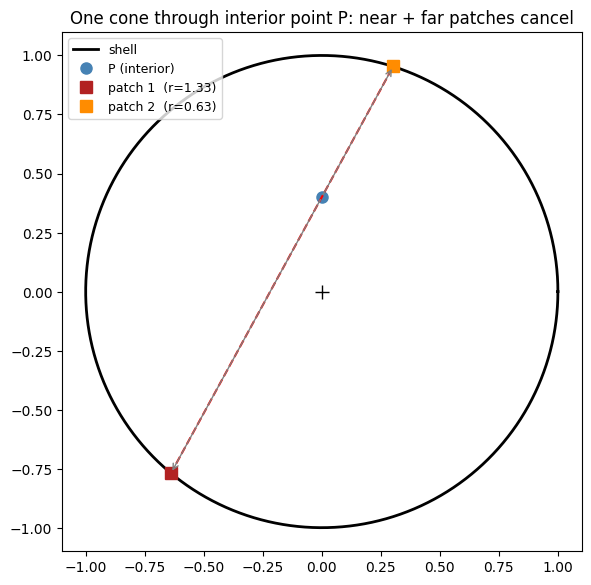

r1=1.3325  r2=0.6304  (unequal distances, equal field contributions)


In [5]:
fig, ax = plt.subplots(figsize=(6,6))
R_val, d_val, alpha_val = 1.0, 0.4, 0.5

theta = np.linspace(0, 2*np.pi, 200)
ax.plot(R_val*np.cos(theta), R_val*np.sin(theta), 'k-', lw=2, label='shell')
ax.plot(0, 0, 'k+', ms=10)
ax.plot(d_val*np.sin(alpha_val*0), d_val, 'o', color='steelblue', ms=8, label='P (interior)')

# ray direction in the x-z plane picture: use (sin a, cos a) as (x,y) here
nx, ny = np.sin(alpha_val), np.cos(alpha_val)
Pv = np.array([0.0, d_val])
nv = np.array([nx, ny])
# solve |P + t n| = R for this 2D cross-section
tt1, tt2 = np.roots([1.0, 2*np.dot(Pv, nv), np.dot(Pv, Pv) - R_val**2])
Q1 = Pv + tt1*nv
Q2 = Pv + tt2*nv

ax.plot(*zip(Q1, Q2), 'r--', lw=1.5)
ax.plot(*Q1, 's', color='firebrick', ms=8, label=f'patch 1  (r={abs(tt1):.2f})')
ax.plot(*Q2, 's', color='darkorange', ms=8, label=f'patch 2  (r={abs(tt2):.2f})')
for Q in (Q1, Q2):
    ax.annotate('', xy=Q, xytext=Pv, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=9)
ax.set_title('One cone through interior point P: near + far patches cancel')
plt.tight_layout()
plt.savefig('griffiths_shell_theorem_geometry.png', dpi=90)
plt.show()
print(f"r1={abs(tt1):.4f}  r2={abs(tt2):.4f}  (unequal distances, equal field contributions)")


## Now put P *outside* the shell ($d>R$) -- same cones, opposite consequence

Re-run the exact same setup with $d>R$. It's cleaner to re-parametrize the ray
by the angle $\gamma$ from the $P\to O$ axis (so $\gamma=0$ points straight at
the center) rather than reuse $\alpha$ from the interior case -- the interior
ray needed to point in an arbitrary direction to reach every part of $4\pi$
steradians around $P$; an exterior ray only ever reaches the shell within a
narrow cone of half-angle $\beta=\arcsin(R/d)$ (the tangent cone), so $\gamma$
measured from the symmetry axis is the natural variable. Same quadratic
structure, same $\hat n\cdot Q_i$ bookkeeping -- **the $\cos\theta_1=-\cos\theta_2$
lemma still comes out true**, unchanged by $d>R$. What changes is what that
lemma *means*: now $t_1,t_2$ are the SAME sign (both roots of
$t_1 t_2=d^2-R^2>0$), so $Q_1$ and $Q_2$ sit on the *same* side of $P$ -- the
near patch and far patch no longer straddle $P$, they're both "ahead" of it.
Equal-magnitude contributions that used to point opposite ways now point the
**same** way and *add*.

In [6]:
gamma, beta = sp.symbols('gamma beta', positive=True)
n_hat_ext = sp.Matrix([sp.sin(gamma), 0, -sp.cos(gamma)])   # points from P toward the sphere (gamma=0 -> straight at O)
P_ext = sp.Matrix([0, 0, d])                                  # now d > R

Q_ext = P_ext + t*n_hat_ext
quad_ext = sp.collect(sp.expand(Q_ext.dot(Q_ext) - R**2), t)
roots_ext = sp.solve(sp.Eq(quad_ext, 0), t)
print("quadratic:", quad_ext, "= 0")
print("roots:", [sp.simplify(r) for r in roots_ext])

# tangent (grazing) angle where the two roots merge (discriminant = 0)
beta_expr = sp.asin(R/d)
disc = sp.simplify((roots_ext[0] - roots_ext[1])**2)
print("\ndiscriminant vanishes (roots merge, grazing incidence) at gamma = beta = asin(R/d):")
print(" ", sp.simplify(disc.subs(gamma, beta_expr)))

cos_theta_ext = [sp.simplify(n_hat_ext.dot(P_ext + ti*n_hat_ext) / R) for ti in roots_ext]
print("\ncos(theta_1) =", cos_theta_ext[0])
print("cos(theta_2) =", cos_theta_ext[1])
lemma_still_holds = sp.simplify(cos_theta_ext[0] + cos_theta_ext[1]) == 0
print("cos(theta_1)+cos(theta_2) =", sp.simplify(cos_theta_ext[0]+cos_theta_ext[1]),
      " -> lemma still holds:", lemma_still_holds)
assert lemma_still_holds

# check a concrete case: looking straight at the center (gamma=0), d=2R -> should give t=d-R, d+R
check = [sp.simplify(r.subs({gamma: 0, R: 1, d: 2})) for r in roots_ext]
print("\nsanity check at gamma=0, R=1, d=2: t =", check, " (expect [1, 3] = d-R, d+R)")
assert sorted(check) == [1, 3]


quadratic: -R**2 + d**2 - 2*d*t*cos(gamma) + t**2*(sin(gamma)**2 + cos(gamma)**2) = 0


roots: [d*cos(gamma) - sqrt(R**2 - d**2*sin(gamma)**2), d*cos(gamma) + sqrt(R**2 - d**2*sin(gamma)**2)]

discriminant vanishes (roots merge, grazing incidence) at gamma = beta = asin(R/d):
  0



cos(theta_1) = -sqrt(R**2 - d**2*sin(gamma)**2)/R
cos(theta_2) = sqrt(R**2 - d**2*sin(gamma)**2)/R
cos(theta_1)+cos(theta_2) = 0  -> lemma still holds: True

sanity check at gamma=0, R=1, d=2: t = [1, 3]  (expect [1, 3] = d-R, d+R)


## Integrate the doubled contribution over the restricted cone

Both patches now contribute field in the **same** direction, $-\hat n$, with
equal magnitude $dE=\dfrac{\sigma}{4\pi\varepsilon_0}\dfrac{d\Omega}{|\cos\theta|}$
each (same formula as before -- the $r^2$ cancellation didn't care about sign
of $d-R$). By azimuthal symmetry only the axial ($z$) component survives once
integrated over $\phi$; that component of $-\hat n$ is $\cos\gamma$. Summing
both patches and integrating $\gamma$ from $0$ to the tangent angle $\beta$:

$$E_z=\int_0^{2\pi}\!\!d\phi\int_0^{\beta}2\cos\gamma\,
\frac{\sigma}{4\pi\varepsilon_0}\frac{\sin\gamma\,d\gamma}{|\cos\theta(\gamma)|}
=\frac{\sigma}{\varepsilon_0}\int_0^{\beta}\frac{R\cos\gamma\sin\gamma}
{\sqrt{R^2-d^2\sin^2\gamma}}\,d\gamma$$

sympy evaluates this -- but it turns out `sp.integrate` mishandles the raw
trig-plus-sqrt-plus-$\arcsin$-bound form directly (caught below by an
independent numeric integral, not just trusted). Substituting $u=\sin\gamma$
first gives sympy an integral it evaluates correctly every time -- no more
hand-waving to Gauss's law, and no silently-wrong symbolic result either.

In [7]:
sigma_s, eps0_s = sp.symbols('sigma epsilon_0', positive=True)

# sp.integrate on the raw gamma-integral (trig + sqrt + asin bound) returns an
# ambiguous Piecewise and, worse, silently picks the wrong branch -- caught
# below by an independent numeric integral, not just trusted. Substituting
# u = sin(gamma) (so cos(gamma) sin(gamma) dgamma = u du) turns it into a
# clean algebraic integral -- but R, d were declared `positive=False` back in
# the interior-case setup (deliberately, to keep that proof fully general),
# and sp.integrate needs a definite sign to resolve sqrt(R^2 - d^2 u^2)
# correctly. Use fresh positive-assumption symbols for this integral only.
R_p, d_p, u = sp.symbols('R d u', positive=True)
integrand_u = u / sp.sqrt(R_p**2 - d_p**2*u**2)
radial_integral = sp.integrate(integrand_u, (u, 0, R_p/d_p))
print("substituted radial integral, 0 to R/d:", radial_integral, " (expect R/d^2)")
assert sp.simplify(radial_integral - R_p/d_p**2) == 0
radial_integral = radial_integral.subs({R_p: R, d_p: d})   # back to the notebook's R, d

E_z_cone = sp.simplify(2*sp.pi * 2 * (sigma_s/(4*sp.pi*eps0_s)) * R * radial_integral)
print("E_z (integrated over phi and gamma) :", E_z_cone)

Q_total_sym = 4*sp.pi*R**2*sigma_s
target = KE.subs(eps0, eps0_s) * Q_total_sym / d**2
print("target k Q / d^2                    :", sp.simplify(target))
assert sp.simplify(E_z_cone - target) == 0
print("\nCone-argument integral EXACTLY reproduces k Q / d^2 -- no Gauss's law invoked.")

# independent numeric cross-check of the ORIGINAL (unsubstituted) gamma
# integral, confirming sp.integrate really was the one going wrong above,
# not this derivation
import scipy.integrate as spi
R_n, d_n = 1.0, 2.0
def integrand_num(g):
    abscos = np.sqrt(R_n**2 - d_n**2*np.sin(g)**2) / R_n
    return 2*np.cos(g)*np.sin(g)/abscos
beta_n = np.arcsin(R_n/d_n)
num_val, _ = spi.quad(integrand_num, 0, beta_n)
Ez_num = num_val * 2*np.pi * (1.0/(4*np.pi))    # sigma=eps0=R=1
print(f"\nnumeric check (R=1, d=2, sigma=eps0=1): E_z={Ez_num:.6f}  vs  k Q/d^2={1.0/d_n**2}")
assert abs(Ez_num - 1.0/d_n**2) < 1e-8


substituted radial integral, 0 to R/d: R/d**2  (expect R/d^2)
E_z (integrated over phi and gamma) : R**2*sigma/(d**2*epsilon_0)
target k Q / d^2                    : R**2*sigma/(d**2*epsilon_0)

Cone-argument integral EXACTLY reproduces k Q / d^2 -- no Gauss's law invoked.



numeric check (R=1, d=2, sigma=eps0=1): E_z=0.250000  vs  k Q/d^2=0.25


## Picture: an exterior point, both patches on the same side

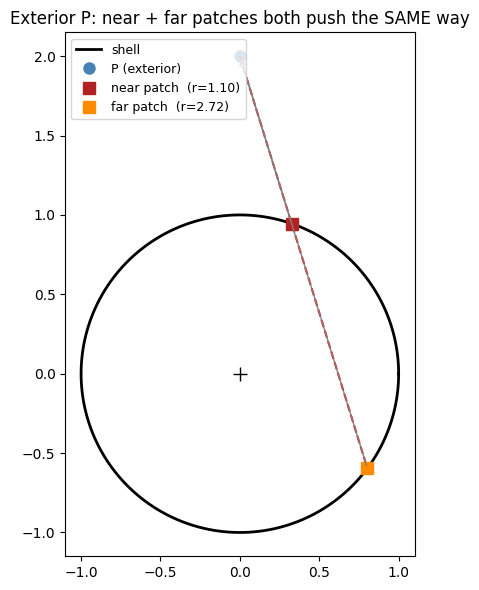

near r=1.1040  far r=2.7173  (both ahead of P, both contribute in the same direction)


In [8]:
fig, ax = plt.subplots(figsize=(6,6))
R_val, d_val, gamma_val = 1.0, 2.0, 0.3

theta = np.linspace(0, 2*np.pi, 200)
ax.plot(R_val*np.cos(theta), R_val*np.sin(theta), 'k-', lw=2, label='shell')
ax.plot(0, 0, 'k+', ms=10)
ax.plot(0, d_val, 'o', color='steelblue', ms=8, label='P (exterior)')

nx, ny = np.sin(gamma_val), -np.cos(gamma_val)
Pv = np.array([0.0, d_val]); nv = np.array([nx, ny])
tt = np.roots([1.0, 2*np.dot(Pv, nv), np.dot(Pv, Pv) - R_val**2])
tt = np.sort(tt)                      # near patch first
Q1, Q2 = Pv + tt[0]*nv, Pv + tt[1]*nv

ax.plot(*zip(Pv, Q2), 'r--', lw=1.5)
ax.plot(*Q1, 's', color='firebrick', ms=8, label=f'near patch  (r={tt[0]:.2f})')
ax.plot(*Q2, 's', color='darkorange', ms=8, label=f'far patch  (r={tt[1]:.2f})')
for Q in (Q1, Q2):
    ax.annotate('', xy=Pv, xytext=Q, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=9)
ax.set_title('Exterior P: near + far patches both push the SAME way')
plt.tight_layout()
plt.savefig('griffiths_shell_theorem_exterior_geometry.png', dpi=90)
plt.show()
print(f"near r={tt[0]:.4f}  far r={tt[1]:.4f}  (both ahead of P, both contribute in the same direction)")


## Cross-check against the repo's existing derivations

`griffiths/electrostatics.py` already has this result two other ways:
`shell_field_coulomb` (direct Coulomb integration, law-of-cosines substitution)
and `gauss_sphere` (Gauss's law). All three methods -- geometric cone argument
(above), brute-force integration, and Gauss's law -- must agree.

In [9]:
sigma, Q_sym, r_sym, R_sym = sp.symbols('sigma Q r R', positive=True)

E_inside_coulomb  = shell_field_coulomb(sigma, R_sym, r_sym, region='inside')
E_outside_coulomb = shell_field_coulomb(sigma, R_sym, r_sym, region='outside')
E_gauss = gauss_sphere(Q_sym, r_sym, R=R_sym, uniform=False)

print('shell_field_coulomb, inside :', E_inside_coulomb, '  (matches the geometric proof: 0)')
print('shell_field_coulomb, outside:', E_outside_coulomb)
print('gauss_sphere (piecewise)    :', E_gauss)

assert E_inside_coulomb == 0
# outside: Coulomb integration returns k*(4 pi R^2 sigma)/r^2 = k Q / r^2 with Q = 4 pi R^2 sigma
Q_total = 4*sp.pi*R_sym**2*sigma
assert sp.simplify(E_outside_coulomb - KE*Q_total/r_sym**2) == 0
print('\nAll three derivations agree: E_inside = 0, E_outside = k Q / r^2.')


shell_field_coulomb, inside : 0   (matches the geometric proof: 0)
shell_field_coulomb, outside: R**2*sigma/(epsilon_0*r**2)
gauss_sphere (piecewise)    : Piecewise((0, R > r), (Q/(4*pi*epsilon_0*r**2), True))

All three derivations agree: E_inside = 0, E_outside = k Q / r^2.


## Numerical cross-check: direct double integral over the shell surface

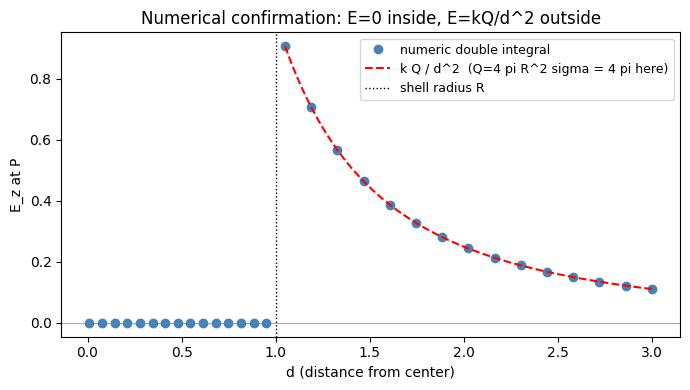

max |E| for d<R (should be ~0): 0.0010355463417876304
E at d=2R vs k Q/d^2          : 0.24999713202682078  vs  0.25


In [10]:
def E_numeric_at(d_val, R_val=1.0, sigma_val=1.0, n=400):
    # integrate Coulomb's law over the shell surface at a point (0,0,d_val)
    theta_g = np.linspace(1e-6, np.pi - 1e-6, n)
    phi_g = np.linspace(0, 2*np.pi, n, endpoint=False)
    TH, PH = np.meshgrid(theta_g, phi_g, indexing='ij')
    x = R_val*np.sin(TH)*np.cos(PH)
    y = R_val*np.sin(TH)*np.sin(PH)
    z = R_val*np.cos(TH)
    dA = R_val**2*np.sin(TH)*(theta_g[1]-theta_g[0])*(phi_g[1]-phi_g[0])
    dq = sigma_val*dA

    rx, ry, rz = 0 - x, 0 - y, d_val - z
    r3 = (rx**2 + ry**2 + rz**2)**1.5
    Ez = np.sum(dq*rz/r3) / (4*np.pi)   # k = 1/(4 pi eps0), eps0=1 for this numeric check
    return Ez

d_vals = np.concatenate([np.linspace(0.01, 0.95, 15), np.linspace(1.05, 3.0, 15)])
E_vals = [E_numeric_at(dv) for dv in d_vals]

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(d_vals, E_vals, 'o', color='steelblue', label='numeric double integral')
d_out = np.linspace(1.05, 3.0, 100)
ax.plot(d_out, 1.0/d_out**2, 'r--', lw=1.5, label='k Q / d^2  (Q=4 pi R^2 sigma = 4 pi here)')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(1.0, color='k', ls=':', lw=1, label='shell radius R')
ax.set_xlabel('d (distance from center)'); ax.set_ylabel('E_z at P')
ax.legend(fontsize=9)
ax.set_title('Numerical confirmation: E=0 inside, E=kQ/d^2 outside')
plt.tight_layout()
plt.savefig('griffiths_shell_theorem_numeric.png', dpi=90)
plt.show()

print('max |E| for d<R (should be ~0):', max(abs(e) for e, dv in zip(E_vals, d_vals) if dv < 1.0))
# k*Q = (1/4 pi eps0)*(4 pi R^2 sigma) = R^2 sigma/eps0 = 1 here (R=sigma=eps0=1), so k Q/d^2 = 1/d^2
print('E at d=2R vs k Q/d^2          :', E_numeric_at(2.0), ' vs ', 1.0/2.0**2)


## Why this only works for $1/r^2$

The whole proof hinged on one cancellation: patch area grows like $r^2$
(more shell subtended at the same solid angle, farther away), and Coulomb's law
falls like $1/r^2$ -- their product is constant. For a general power law
$1/r^n$, the same bookkeeping gives $dE_i\propto r_i^{2-n}$, which only cancels
between the two patches when $n=2$. Newton's shell theorem (gravity) and
Gauss's law both work *because* they're inverse-square laws, and this geometric
argument is the cleanest way to see that dependency isn't a coincidence.

In [11]:
n_sym = sp.Symbol('n', positive=True)
# dE_i / (sigma dOmega/(4 pi eps0)) generalized to a 1/r^n force law:
dE_general = [sp.simplify(ri**(2-n_sym) / sp.Abs(ct)) for ri, ct in zip(r_dists, cos_theta)]
diff_n = sp.simplify(dE_general[0] - dE_general[1])
print('dE_1 - dE_2 for general 1/r^n law:', diff_n)
print('\nSetting n=2 (inverse square):', sp.simplify(diff_n.subs(n_sym, 2)), '  (cancels, as proved above)')
print('Setting n=3 (say):', sp.simplify(diff_n.subs(n_sym, 3)), '  (generically nonzero -- no shell theorem)')


dE_1 - dE_2 for general 1/r^n law: R*(-1/Abs((d*cos(alpha) + sqrt(R**2 - d**2*sin(alpha)**2))**(n - 2)) + 1/Abs((d*cos(alpha) - sqrt(R**2 - d**2*sin(alpha)**2))**(n - 2)))/Abs(sqrt(R**2 - d**2*sin(alpha)**2))

Setting n=2 (inverse square): 0   (cancels, as proved above)


Setting n=3 (say): R*(-1/Abs(d*cos(alpha) + sqrt(R**2 - d**2*sin(alpha)**2)) + 1/Abs(d*cos(alpha) - sqrt(R**2 - d**2*sin(alpha)**2)))/Abs(sqrt(R**2 - d**2*sin(alpha)**2))   (generically nonzero -- no shell theorem)
